In [189]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import graphviz
import random

In [53]:
import os

os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

In [190]:
class Value:
    def __init__(self,data,_children=(),_op='', label=''):
        self.data=data
        self.grad=0.0 #we assume that initially nothing imacts loss function
        self._backward= lambda: None
        self._prev=set(_children)
        self._op=_op
        self.label=label
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self,other):
        other =other if isinstance(other,Value) else Value(other)
        out = Value(self.data+other.data , (self,other),'+')
        def _backward():
            self.grad+=1.0* out.grad
            other.grad+=1.0 * out.grad
        out._backward= _backward
        return out
        
    def __mul__(self,other):
        other =other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data , (self,other),'*')
        def _backward():
            self.grad+=other.data * out.grad
            other.grad+=self.data*out.grad
        out._backward=_backward
        return out
        
    def __pow__(self,other):
        assert isinstance(other,(int , float))
        out = Value(self.data**other,(self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward
        return out
    def __radd__(self, other):
        return self + other
    def __rmul__(self,other): #other*self
        return self*other
    
    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * (other ** -1)

    def __neg__(self):
        return self*-1
    def __sub__(self,other):
        return self+(-other)
        
    def tanh(self):
        x=self.data
        t= (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t,(self,),'tanh' )

        def _backward():
            self.grad+= (1- t**2) *out.grad
        out._backward= _backward
        return out
        
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad+=self.data*out.grad
        out._backward= _backward
        return out
        
    def backward(self):
        topo =[]
        visited =set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad =1.0
        for node in reversed(topo):
            node._backward()
        
a= Value(2.0, label='a')
b= Value(-3.0, label='b')
c= Value(10.0, label='c')
e= a*b; e.label = 'e'
d= e + c; d.label = 'd '
f = Value(-2.0, label='f')
L=d*f; L.label='L'
L



Value(data=-8.0)

In [109]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes , edges = set(), set()
    def build (v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'}) #LR= left to right

    nodes,edges= trace(root)
    for n in nodes:
        uid=str(id(n))
        #for any value in the graph , create a rectangular ('record') node for it
        dot.node(name=uid,label = "{ %s | data %.4f | grad %.4f}" %(n.label,n.data,n.grad), shape='record')
        if n._op:
            #if this value is a result of some operation , create an op node for it 
            dot.node(name=uid+n._op,label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op,uid)
    for n1,n2 in edges:
        #connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2)) + n2._op)
    return dot

In [75]:
# now this is forward propagation what we are intrested
# is in back propagation we will be calculating gradient of the loss funtion 
# w.r.t all the leaf nodes 
#we will create a variable in value class that maintains the gradient

In [76]:
#L= d* f
#dL/dd=? -> f
#(f(x+h)-f(x))/h-> this essentially means ((d+h)*f - d*f)/h -> solve -> f


In [58]:
L.grad=1.0
f.grad=4.0
d.grad= -2.0
c.grad= -2.0
e.grad =-2.0
a.grad= -2.0 * -3.0
b.grad= -2.0 * 2.0
#dL/dc= dL/dd * dd/dc
# so i case of plus sign the value for d is just copied to both c and e gradients
# also as u can see dL/dd defends on the value of f and since dd/dc is a const 1 
# therefore it also depends on the value of f
#the plus node will just distribute the gadient to the leaf nodes
#similarly dL/da will be b and vice verca dL/db is a

In [59]:
#now what we are going to do is we will move the data in the direction of the gradient to 
# to find the global maximum or minimum values of the loss function
#Gradient Ascent (Finding the Peak): If you want to maximize a score (like maximizing 
#   a company's profit based on different variables), you calculate the gradient at your 
#   current position and take a step in that direction. You keep doing this until
#   the ground levels out, meaning you've reached the top.
#Gradient Descent (Finding the Valley): In machine learning and neural networks,
#   we want to minimize our error (how wrong the AI's guesses are). So, we calculate 
#   the gradient (the steepest way up) and take a step in the exact opposite direction
#   (the steepest way down). We keep walking downhill until we reach the bottom of 
#   the valley where the error is zero.

# now we are udating the leaf nodes data  =>  x.data += learning_rate * x.grad

In [60]:
a.data+= 0.01 * a.grad
b.data+= 0.01 * b.grad
c.data+= 0.01 * c.grad
f.data+= 0.01 * f.grad

# now we have to give the forward pass again
e= a * b
d= e + c
L= d * f

print(L.data)

-7.286496


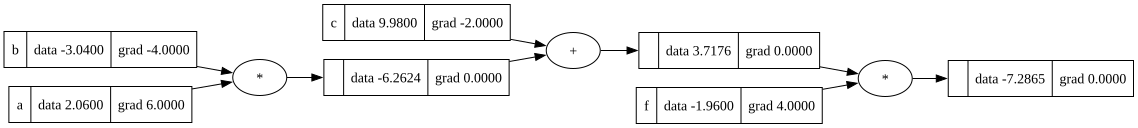

In [61]:
draw_dot(L)

In [62]:
#NOW WE WILL LOOK AT ANOTHER EAXMPLE BUT A BIT TOUGH AND ACTUAL REAL WORD BASED SOMETHING LIKE

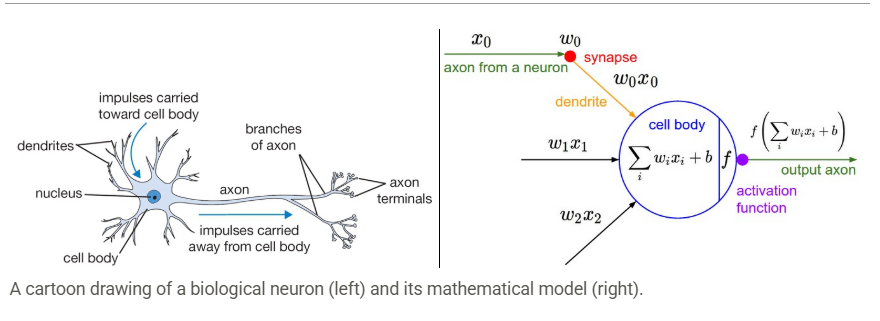

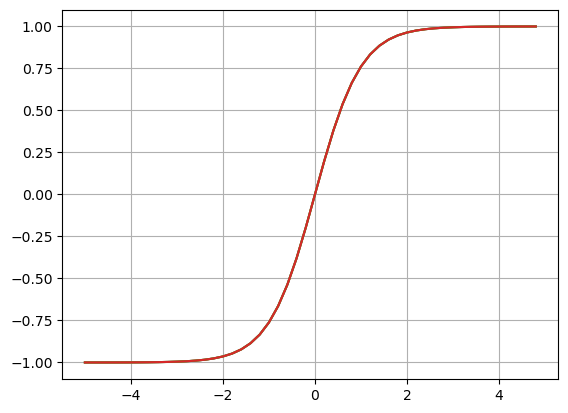

In [71]:
x = np.arange(-5, 5, 0.2)
plt.plot(x, np.tanh(x))
plt.show()

In [ ]:
# this is basically used as a activation function

In [166]:
#inputs x1,x2
x1= Value(2.0, label='x1')
x2= Value(0.0, label='x2')
#weights w1,w2
w1= Value(-3.0 , label='w1')
w2= Value(1.0 , label='w2')
#bias of the neuron
#here we are selcting bias as a strange value to et the numbers corrct for back propagation
b= Value(6.8813735870195432,label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2 ;x1w1x2w2.label='x1w1 + x2w2'
n= x1w1x2w2 +b; n.label='n'
o= n.tanh(); o.label='o'
o.backward()

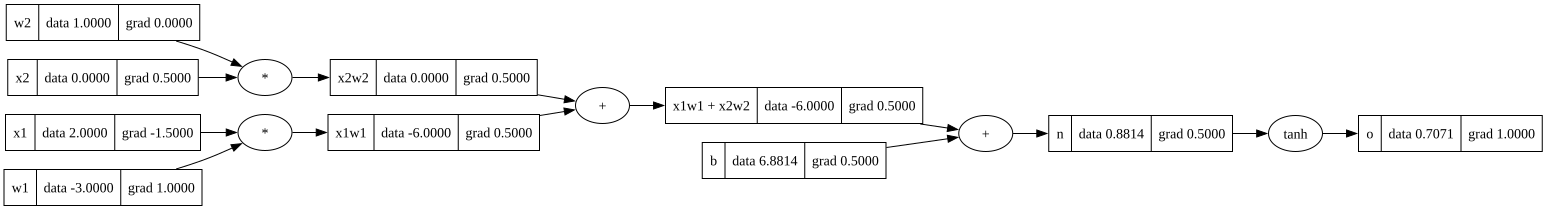

In [167]:
draw_dot(o)

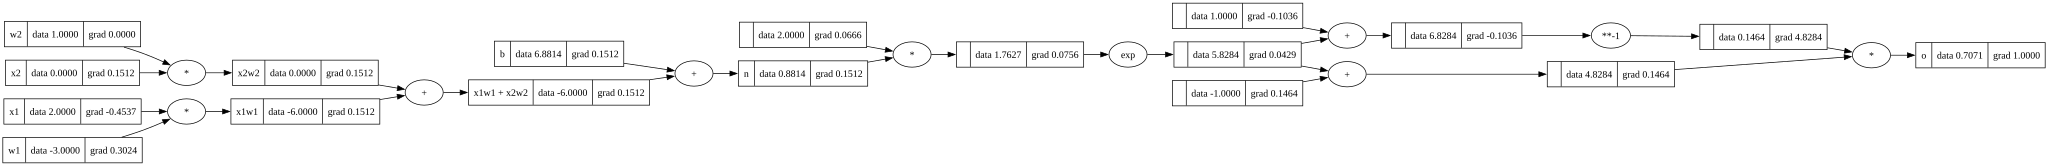

In [176]:
#inputs x1,x2
x1= Value(2.0, label='x1')
x2= Value(0.0, label='x2')
#weights w1,w2
w1= Value(-3.0 , label='w1')
w2= Value(1.0 , label='w2')
#bias of the neuron
#here we are selcting bias as a strange value to et the numbers corrct for back propagation
b= Value(6.8813735870195432,label='b')
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2 ;x1w1x2w2.label='x1w1 + x2w2'
n= x1w1x2w2 +b; n.label='n'
#-------------
e= (2*n).exp()
o=(e-1)/(e+1)
#--------------
o.label='o'
o.backward()
draw_dot(o)

In [129]:
#now we dont want to caall backprpgation manually everytime 
# what we will use is something called topological sort what it does it sorts the graph so all the edges go from left to right

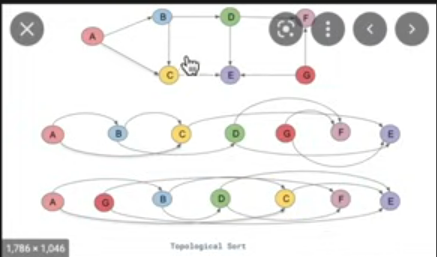

In [131]:
topo =[]
visited =set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=2.0),
 Value(data=-1.4999999999999996),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=0.4999999999999999),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [116]:
#now doing it automatically by calling in right order
o.grad = 1.0 # coz above initiased o.grad as 0


In [119]:
o._backward()

In [121]:
n._backward()

In [123]:
b._backward()

In [125]:
x1w1x2w2._backward()

In [127]:
x2w2._backward()
x1w1._backward()


In [106]:
#now we will calculate gradient
n.grad=0.5
o.grad=1.0
x1w1x2w2.grad=1*n.grad #coz of plus sign
b.grad=1*n.grad #coz of plus sign
x1w1.grad=1*x1w1x2w2.grad #coz of plus sign
x2w2.grad=1*x1w1x2w2.grad #coz of plus sign
x2.grad=w2.data * x2w2.grad
w2.grad=x2.data * x2w2.grad

x1.grad=w1.data * x1w1.grad
w1.grad=x1.data * x1w1.grad

In [84]:
#o=tanh(n)
#do/dn=? -> 1-tanh(n)**2 ->1-o**2
1-o.data**2
# 5 convinently

0.4999999999999999

In [177]:
#NOW WE WILL DO BACKWARD PASSING WITHOUT DOING MANUAL LEST GO ABCK TO VALUE AND CODE!!!!!

In [181]:
!pip install torch

In [183]:
import torch

In [184]:
x1= torch.Tensor([2.0]).double()                   ; x1.requires_grad = True
x2= torch.Tensor([0.0]).double()                   ; x2.requires_grad = True
w1= torch.Tensor([-3.0]).double()                  ; w1.requires_grad = True
w2= torch.Tensor([1.0]).double()                   ; w2.requires_grad = True
b= torch.Tensor([6.8813735870195432]).double()     ; b.requires_grad = True
n= x1*w1+x2*w2 +b
o=torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


#now we will start building our neural nets!!!!

In [196]:
class Neuron:
    def __init__(self,nin):
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b= Value(random.uniform (-1,1))

    def __call__(self,x):
        #w*x+b -> w*x is a dot product
        act = sum((wi*xi for wi , xi in zip(self.w,x)),0.0) +self.b #->> zip = what this does is take a x and multiply it with its weight it basicaaly take stwo iterators and then take a third iterator to iterate ove the tuple of corresponding entries
        out = act.tanh()
        return out 
x=[2.0,3.0]
n=Neuron(2)
n(x)#-> using this python will call __call__
        

Value(data=-0.974710063252281)